<a href="https://colab.research.google.com/github/matteotiraboschi13/amh-eurostoxx50-test/blob/main/notebooks/02_AMH_Europe_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Initial Setup**

To connect the local runtime, I created the AMH_REPLICA folder containing the files from Drive. Then I opened that folder, clicked on the path bar, and typed cmd. After that, I have run the following commands:

In [2]:
# tfgpu310\Scripts\activate
# jupyter notebook --NotebookApp.allow_origin="https://colab.research.google.com" --port=8888 --NotebookApp.port_retries=0

Once I have run the code, a **token** appeared. Then I opened Colab, clicked Connect to local runtime, and entered the token.

I import the required libraries.

In [3]:
import os                                                                       # for working with files and folders
import numpy as np                                                              # for arrays and numerical calculations
import pandas as pd                                                             # for working with dataframes and time series
import matplotlib.pyplot as plt                                                 # for creating plots
import matplotlib.dates as mdates                                               # for handling and formatting dates in plots
import tensorflow as tf                                                         # for building and training neural networks
import sys, torch                                                               # sys for running pip, torch is PyTorch for neural networks
import altair as alt                                                            # another library for interactive plots
from tensorflow.keras import Model                                              # for creating models with Keras
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout                 # layers that i will use in the model
from tensorflow.keras.models import Sequential                                  # for building LSTM and MLP
from tensorflow.keras.optimizers import Adam                                    # Adam optimizer for training
from matplotlib.patches import Ellipse                                          # for drawing ellipses in plots
from scipy.stats import ansari                                                  # Ansari-Bradley test for comparing the dispersion of two samples
from sklearn.preprocessing import StandardScaler                                # for standardizing the features
from matplotlib.ticker import FormatStrFormatter                                # for ticker

I check which Python version the notebook is using and whether both **torch** and **tensorflow** detect the GPU.


In [4]:
print("FOLDER:", os.getcwd())
print("PYTHON:", sys.executable)
print("TF VERSION:", tf.__version__)
print("TF GPU:", tf.config.list_physical_devices("GPU"))
print("TORCH VERSION:", torch.__version__)
print("TORCH CUDA:", torch.cuda.is_available())
print("TORCH GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

FOLDER: C:\Users\Marco\Desktop\Universita\Tesi\AMH_REPLICA
PYTHON: C:\Users\Marco\Desktop\Universita\Tesi\AMH_REPLICA\tfgpu310\Scripts\python.exe
TF VERSION: 2.10.1
TF GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TORCH VERSION: 2.5.1+cu121
TORCH CUDA: True
TORCH GPU: NVIDIA GeForce GTX 1050


Code to run if i use the Colab runtime.

In [5]:
#from google.colab import drive
#drive.mount('/content/drive')

I set the pandas options to display all columns on a single line.

In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

# **Model Configuration**

Now i set the **macro parameters** for the model execution.

In [7]:
SEED = 42                                                                       # seed for reproducibility                  # if i use drive
DATA_PATH = "processedDataset/datasetEU.csv"                                           # dataset path
VSTOXX_FILE = "processedDataset/VSTOXX.csv"                                            # VSTOXX file path

START_DATE = "2004-09-06"                                                       # start date
END_DATE = "2026-02-28"                                                         # end date

TARGET = "EUROSTOXX50_ret"
FEATURES = ["BRENTOIL_ret","SR5Y","SR10Y","SR30Y","EONIA_ESTR","LOGM2REAL","EURO_ret"]

TIME_STEPS = 12                                                                 # number of time steps
HIDDEN = 10                                                                     # neuron in hidden layer
EPOCHS = 50                                                                     # number of epochs
BATCH_SIZE = 32                                                                 # i make an assumption, since i do not find this information in the paper
CHECKPOINT_STEP = 10                                                            # checkpoint step (every fornight)
TRAIN_YEARS = {"1Y": 1,"10Y": 10}                                               # train years, try 1Y or 10Y
HORIZONS = {"2M": 42, "6M": 126}                                                # test horizons, try 2M or 6M
DROPOUT = 0.20                                                                  # dropout for MLP

# **Function Definitions**

Now i define some functions that i will reuse several times, so that the code is more organized and less repetitive.

I define the function for **loading the dataset**, converting the date into DateTime format and filtering it for the selected period.

In [8]:
def load_data(path):
    df = pd.read_csv(path)                                                      # load dataset from csv
    df["Date"] = pd.to_datetime(df["Date"])                                     # convert the date in datetime
    df = df[(df["Date"] >= START_DATE) & (df["Date"] <= END_DATE)].reset_index(drop=True)   # filter for data and reset the index

    return df                                                                   # return dataset

I define the function that generates the input-target pairs $(X_i, y_i)$, where $X_i$ represents a time window composed of the last $k = 12$ observed feature vectors, while $y_i$ is the corresponding scalar target.

$$
(X_i, y_i) = \left( [x_{t-12}, x_{t-11}, \ldots, x_{t-1}],\; y_t \right)
$$

that is,

$$
X_i = [x_{t-k}, \dots, x_{t-1}]
$$

where each $x_t$ is a 7-dimensional feature vector observed at time $t$,

$$
x_t = [r^{oil}_t,\ y^{(5)}_t,\ y^{(10)}_t,\ y^{(30)}_t,\ EONIA\_ESTR_t,\ log(M2REAL_t),\ r^{eur}_t]
$$

and the target variable,

$$
y_t = r^{EUROSTOXX50}_t \in \mathbb{R}.
$$

In [9]:
def create_sequence(df):
    features = df[FEATURES]                    # assign the features
    target = df[TARGET]                        # assign the target
    dates = df["Date"]                         # save the date in dates

    X, y, d = [], [], []                       # initialize the empty vectors
    for t in range(TIME_STEPS, len(df)):       # run the cicle from TIME_STEPS to len(df)
        X.append(features[t - TIME_STEPS:t])   # it is a vector 12 x 7 : features[0:12], features[1:13] ... [0:12] it goes from 0 to 11
        y.append(target[t])                    # return at time t : target[12], target[13] ... [12] take the 12th element
        d.append(dates[t])                     # date at index t : dates[12], dates[13] ...

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), d      # conevert X, y in array and in float 32(default of tensorflow) and returnt the data d

The input features are standardized before training. Standardization transforms each variable as

$$
z = \frac{x - \mu}{\sigma}
$$

where  $\mu$ and  $\sigma$ are the **mean** and **standard deviation** of the feature. This **makes the variables more comparable**, even if they are measured on different scales, and **helps the model train more efficiently**.

The scaler is fitted only on the training set and then applied to the test set using the same parameters. This is done to avoid **data leakage**, since fitting the scaler on the test set would **use information that should not be available during training**.


In [10]:
def scale(df_train, df_test):
    scaler = StandardScaler()                                                   # create scaler
    df_train[FEATURES] = scaler.fit_transform(df_train[FEATURES])               # fit only on train
    df_test[FEATURES]  = scaler.transform(df_test[FEATURES])                    # tranform on test

    return df_train, df_test                                                    # return scaled df

I define the function that builds the **LSTM** model with an **MLP head.**

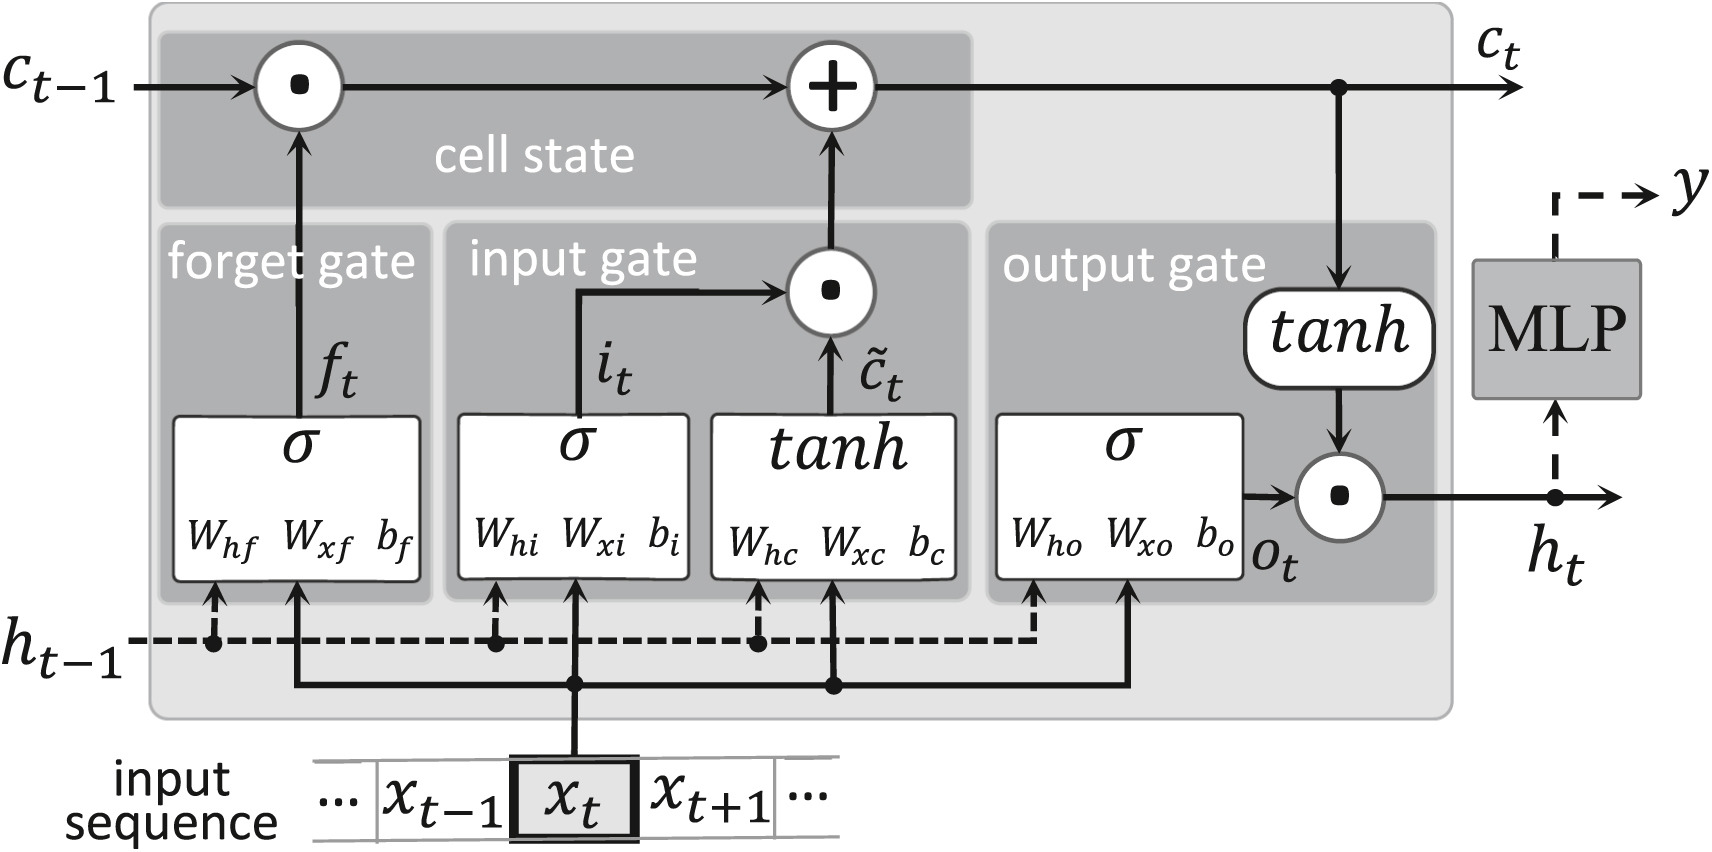

*Figure. Schematic representation of the LSTM architecture with MLP head used in the model.*

In [11]:
def build_lstm():
    model = Sequential()                                              # create an empty sequential model
    model.add(Input(shape=(TIME_STEPS, len(FEATURES))))               # add an input with shape (12,7)
    model.add(LSTM(HIDDEN, name="lstm"))                              # take the sequence and have it processed by an LSTM, with HIDDEN = number of neurons in the hidden state
    model.add(Dense(HIDDEN, activation="relu", name="mlp_head"))      # take the vector produced by the LSTM and pass it to a Dense layer that represents the MLP head
    model.add(Dense(1, activation="linear", name="out"))              # take the vector and produce the final output (prediction of Yt)
    model.compile(optimizer=Adam(), loss="mse")                       # i prepare the model for training and update the weights by minimizing the MSE

    return model                                                      # return a keras object

I define the function that creates the **MLP** model.

In [12]:
def build_mlp():
    model = Sequential()                                               # create an empty sequential model
    model.add(Input(shape=(TIME_STEPS * len(FEATURES),)))              # we define the input shape: (84,) which is a flat vector 12*7
    model.add(Dense(HIDDEN, activation="relu", name="mlp_hidden"))     # take the sequence and have it processed by a Dense layer, with HIDDEN = number of neurons in the hidden state
    model.add(Dropout(DROPOUT, name="mlp_dropout"))                    # dropout during training randomly turns off a certain percentage of neurons (to reduce overfitting)
    model.add(Dense(1, activation="linear", name="out"))               # take the vector and produce the final output (prediction of Yt)
    model.compile(optimizer=Adam(), loss="mse")                        # i prepare the model for training and update the weights by minimizing the MSE

    return model                                                       # return a keras object

I define the function for the **reproducibility** of the results.

In [13]:
def set_seed(seed=SEED):
    tf.random.set_seed(seed)

I define the function to compute the **RMSE** error, which takes y_true and y_pred as inputs.
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

In [14]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

I define the function to compute the **RMDSE** error, which takes y_true and y_pred as inputs.
$$RMDSE = \sqrt{\text{median} \left( (y_i - \hat{y}_i)^2 \right)}$$

In [15]:
def rmdse(y_true, y_pred):
    return float(np.sqrt(np.median((y_true - y_pred) ** 2)))

In this **function**, for each combination of model type, training years, and test horizon, we run the model over the whole time series.

For example, for $K = 252$ , $M = 42$ and $TIME\_STEPS=12$. In this case, $\texttt{first_p} = 252$, while $\texttt{last_p} = 5509 - 12 - 42 = 5455$. At this point, we run a $\texttt{for}$ loop in which, for each value of $p$ in the interval $[252, 5456]$, moving forward by $10$ observations at a time, we construct the training and test indices.

For instance, if $p = 252$, then:

$$
\texttt{tr} = [p-K : p+12] = [252-252 : 252+12] = [0 : 264]
$$

and

$$
\texttt{te} = [p : p+M+12] = [252 : 252+42+12] = [252 : 306]
$$

This construction is necessary because, in the next step, time sequences are created from these observations. In fact, each sequence requires at least $12$ past rows to be built. As a result, with $264$ rows in the training set we can generate $252$ sequences, while with $54$ rows in the test set we can generate $42$ sequences.

After that, the training and test data are scaled using the scaling function, and only then the sequences used in that specific checkpoint are created for training and testing.

Finally, the model is fitted and the results are stored.

In [16]:
def run_model(df, model_type, train_years_name, horizon_name):
    train_years = TRAIN_YEARS[train_years_name]                                 # find the training years es: 1Y = 1
    horizon_days = HORIZONS[horizon_name]                                       # find the horizon days es: 2M = 42

    K = 252 * train_years                                                       # how many past observations i use to train the model es: 1Y = 252 days
    M = horizon_days                                                            # test period length es: 2M = 42 days

    first_p = K                                                                 # first test index, so there must be K training observations before
    last_p = len(df) - TIME_STEPS - M                                           # last test index from which i can still take M observations

    rows = []                                                                   # initialize rows which will contain the results of each checkpoint
    for p in range(first_p, last_p + 1, CHECKPOINT_STEP):                       # for each p, starting from first_p and going up to last_p + 1 moving by CHECKPOINT_STEP
        tr = slice(p - K, p + TIME_STEPS)                                       # train row from p-K to p+TIME_STEPS es: [0,264], [10,274] ...
        te = slice(p, p + M + TIME_STEPS)                                       # test row from p to p+M+TIME_STEPS es: [252,306], [262,316] ...

        df_train = df.iloc[tr].reset_index(drop=True)                           # create the train df filtering df with tr es: df_train = df[0,264]
        df_test  = df.iloc[te].reset_index(drop=True)                           # create the test dffiltering df with te es: df:test = df[252,306]

        df_train, df_test = scale(df_train, df_test)                            # scale the df_train and the df_test

        X_train, y_train, dates = create_sequence(df_train)                     # now i create train sequences after scaling
        X_test, y_test, dates   = create_sequence(df_test)                      # now i create test sequences after scaling

        tf.keras.backend.clear_session()                                        # clean the keras session
        set_seed(SEED)                                                          # set the seed for the reproducibility

        if model_type == "LSTM":                                                # if the model is LSTM
            model = build_lstm()                                                # build the LSTM model
        elif model_type == "MLP":                                               # if the model is MLP
            model = build_mlp()                                                 # build the MLP model
            X_train = X_train.reshape(len(X_train), -1)                         # flatten because MLP does not process sequences
            X_test = X_test.reshape(len(X_test), -1)                            # flatten because MLP does not process sequences

        model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)  # train the model on X_train and y_train
        y_pred = model(X_test, training=False).numpy().ravel()                  # ravel() for obtain a 1D vector

        checkpoint_date = df_train["Date"].iloc[-1]                             # take the last observation

        rows.append({"model": model_type,"train_years": train_years_name,"horizon": horizon_name,"horizon_days": horizon_days,"checkpoint_index": p,
            "checkpoint_date": checkpoint_date,"rmse": rmse(y_test, y_pred),"rmdse": rmdse(y_test, y_pred),})

        print(f"[{model_type}] {train_years_name} {horizon_name} | p={p} | {checkpoint_date.date()} | RMSE={rows[-1]['rmse']:.5f} | RMDSE={rows[-1]['rmdse']:.5f}")

    return pd.DataFrame(rows)                                                   # transform rows in DataFrame and return it

I define a function that **plots the RMSE graphs** of the various models.

In [23]:
def plot_rmse(results, model_name, horizon, vstoxx):

    sub = results[(results["model"] == model_name) & (results["horizon"] == horizon)].copy()   # filter by model and horizon
    sub["checkpoint_date"] = pd.to_datetime(sub["checkpoint_date"])                            # convert result dates
    vstoxx["Date"] = pd.to_datetime(vstoxx["Date"])                                            # convert VSTOXX dates

    fig, ax = plt.subplots(figsize=(12, 3.7))                                                    # create figure and main axis

    styles = {
        "1Y":  {"color": "#0c6fc2", "linestyle": "-",  "label": "1Y train"},
        "10Y": {"color": "#4dce56", "linestyle": "--", "label": "10Y train"},
    }                                                                                          # style of the two series

    for y in ["1Y", "10Y"]:                                                                    # loop only over the two training windows used in the paper
        w = sub[sub["train_years"] == y].sort_values("checkpoint_date")                        # filter the current series
        if w.empty:   continue
        ax.plot(w["checkpoint_date"],w["rmse"] / 100,color=styles[y]["color"],linestyle=styles[y]["linestyle"],lw=0.8,label=styles[y]["label"])  # plot the RMSE series

    ax2 = ax.twinx()                                                                           # create the second y-axis
    ax2.fill_between(vstoxx["Date"], vstoxx["VSTOXX"], 0,color="red", alpha=0.08, linewidth=0, edgecolor="none", label="VSTOXX") # draw the VSTOXX as a shaded area

    ax.set_title(f"{model_name} {horizon}", fontsize=10.5, fontweight="bold")                  # set the title
    ax.xaxis.set_major_locator(mdates.YearLocator(5))                                          # one label every 5 years
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))                                   # show only the year on the x-axis

    ax.spines["top"].set_visible(False)                                                        # hide top border of the main axis
    ax.spines["right"].set_visible(False)                                                      # hide right border of the main axis
    ax2.spines["top"].set_visible(False)                                                       # hide top border of the secondary axis
    ax2.spines["left"].set_visible(False)                                                      # hide left border of the secondary axis

    ax.set_xlabel("YEAR", fontsize=9)                                                          # set x-axis label
    ax.set_ylabel("RMSE", fontsize=9, color="#0c6fc2")                                         # set left y-axis label
    ax2.set_ylabel("VSTOXX", fontsize=9, color="#e8815f")                                      # set right y-axis label

    ax.spines["left"].set_color("#0c6fc2")                                                     # color the left axis
    ax.tick_params(axis="y", colors="#0c6fc2")                                                 # color the left-axis ticks

    ax2.spines["right"].set_color("#e8815f")                                                   # color the right axis
    ax2.tick_params(axis="y", colors="#e8815f")                                                # color the right-axis ticks

    ax2.set_ylim(bottom=0)                                                                     # start the VSTOXX axis from zero

    lines1, labels1 = ax.get_legend_handles_labels()                                           # get legend from main axis
    lines2, labels2 = ax2.get_legend_handles_labels()                                          # get legend from secondary axis
    ax.legend(lines1 + lines2, labels1 + labels2, frameon=False)                               # merge everything into one legend

    ax.set_xlim(sub["checkpoint_date"].min(), sub["checkpoint_date"].max())                    # remove empty space on the x-axis
    ax.margins(x=0)                                                                            # remove horizontal padding
    ax2.margins(x=0)                                                                           # remove horizontal padding on secondary axis

    plt.tight_layout()                                                                         # adjust spacing
    plt.show()                                                                                 # display the plot

# **Identification of high-uncertainty events through VSTOXX**

I call the function and save the cleaned dataframe, ready to be plotted.

In [21]:
vstoxx_df = load_data(VSTOXX_FILE)                                                    # load and clean the VSTOXX

Now i show the plot of **VSTOXX**, in order to highlight the main **peaks** associated with the **crisis events** analyzed.


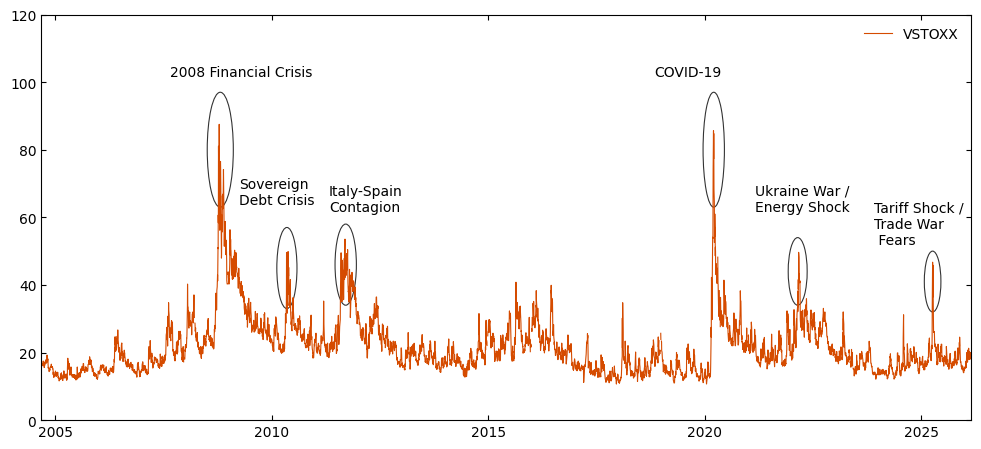

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.6))                                         # create the figure and the plot axis

ax.plot(vstoxx_df["Date"], vstoxx_df["VSTOXX"], lw=0.8, color="#d54b00", label="VSTOXX")    # plot the VSTOXX series

ax.set(xlabel="",ylabel="",ylim=(0, 120),xlim=(pd.to_datetime(START_DATE), pd.to_datetime(END_DATE)),) # i set the time range and y-axis limits

ax.grid(False)                                                                  # remove the grid
ax.spines["top"].set_visible(True)                                              # show the top border
ax.spines["right"].set_visible(True)                                            # show the right border
ax.tick_params(axis="both", which="both", top=True, right=True, direction="in") # add ticks also on top and right
ax.legend(frameon=False, loc="upper right")                                     # add the legend in the upper-right corner
ax.yaxis.set_major_locator(plt.MultipleLocator(20))                             # set y-axis ticks every 20 points
ax.tick_params(labelsize=10)                                                    # set tick label size
ax.xaxis.set_major_locator(mdates.YearLocator(5))                               # place one tick every 5 years on the x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))                        # format x-axis ticks to show only the year

events = [
    ("2008-10-25", 80, 220, 34, "2007-09-01", 105, "2008 Financial Crisis", "left", "top"),
    ("2010-05-10", 45, 170, 24, "2009-04-01", 72, "Sovereign\nDebt Crisis", "left", "top"),
    ("2011-09-18", 46, 180, 24, "2011-05-01", 70, "Italy-Spain\nContagion", "left", "top"),
    ("2020-03-18", 80, 180, 34, "2018-11-01", 105, "COVID-19", "left", "top"),
    ("2022-02-24", 44, 160, 20, "2021-03-01", 70, "Ukraine War /\nEnergy Shock", "left", "top"),
    ("2025-04-07", 41, 140, 18, "2023-12-01", 65, "Tariff Shock /\nTrade War\n Fears", "left", "top"),
]

for d, y, w, h, tx, ty, label, ha, va in events:                                # loop over the crisis events to highlight
    ax.add_patch(Ellipse((mdates.date2num(pd.to_datetime(d)), y), w, h, fill=False, edgecolor="black", lw=0.8, alpha=0.8))  # i draw an ellipse around the event
    ax.text(pd.to_datetime(tx), ty, label, ha=ha, va=va, fontsize=10)           # add the event label

plt.tight_layout()                                                              # adjust the spacing
plt.show()                                                                      # display the plot

# **Model Training & Evaluation**

Now i call the functions and run the models.

In [ ]:
set_seed()                                                # seed for reproducibility
df = load_data(DATA_PATH)                                 # load dataset
results = pd.DataFrame()                                  # initial empty dataframe

Now i run the **LSTM 1Y 2M** model, and save the results.

In [ ]:
res = run_model(df, "LSTM", "1Y", "2M")
results = pd.concat([results, res], ignore_index=True)

[LSTM] 1Y 2M | p=252 | 2005-09-14 | RMSE=0.90435 | RMDSE=0.49241
[LSTM] 1Y 2M | p=262 | 2005-09-28 | RMSE=0.79244 | RMDSE=0.42050
[LSTM] 1Y 2M | p=272 | 2005-10-12 | RMSE=0.79622 | RMDSE=0.42964
[LSTM] 1Y 2M | p=282 | 2005-10-26 | RMSE=0.85251 | RMDSE=0.51088
[LSTM] 1Y 2M | p=292 | 2005-11-09 | RMSE=0.53841 | RMDSE=0.36333
[LSTM] 1Y 2M | p=302 | 2005-11-23 | RMSE=0.68113 | RMDSE=0.43477
[LSTM] 1Y 2M | p=312 | 2005-12-07 | RMSE=0.70538 | RMDSE=0.36850
[LSTM] 1Y 2M | p=322 | 2005-12-21 | RMSE=0.78347 | RMDSE=0.47750
[LSTM] 1Y 2M | p=332 | 2006-01-05 | RMSE=0.80694 | RMDSE=0.47556
[LSTM] 1Y 2M | p=342 | 2006-01-19 | RMSE=0.79927 | RMDSE=0.48385
[LSTM] 1Y 2M | p=352 | 2006-02-02 | RMSE=0.68656 | RMDSE=0.47103
[LSTM] 1Y 2M | p=362 | 2006-02-16 | RMSE=0.75856 | RMDSE=0.43364
[LSTM] 1Y 2M | p=372 | 2006-03-02 | RMSE=0.66211 | RMDSE=0.46673
[LSTM] 1Y 2M | p=382 | 2006-03-16 | RMSE=0.95438 | RMDSE=0.47540
[LSTM] 1Y 2M | p=392 | 2006-03-30 | RMSE=1.21854 | RMDSE=0.80292
[LSTM] 1Y 2M | p=402 | 20

Now i run the **LSTM 1Y 6M** model, and save the results.

In [ ]:
res = run_model(df, "LSTM", "1Y", "6M")
results = pd.concat([results, res], ignore_index=True)

[LSTM] 1Y 6M | p=252 | 2005-09-14 | RMSE=0.76038 | RMDSE=0.47282
[LSTM] 1Y 6M | p=262 | 2005-09-28 | RMSE=0.76270 | RMDSE=0.51327
[LSTM] 1Y 6M | p=272 | 2005-10-12 | RMSE=1.03626 | RMDSE=0.79603
[LSTM] 1Y 6M | p=282 | 2005-10-26 | RMSE=0.75520 | RMDSE=0.44439
[LSTM] 1Y 6M | p=292 | 2005-11-09 | RMSE=0.70687 | RMDSE=0.41404
[LSTM] 1Y 6M | p=302 | 2005-11-23 | RMSE=0.84136 | RMDSE=0.47555
[LSTM] 1Y 6M | p=312 | 2005-12-07 | RMSE=0.96319 | RMDSE=0.54116
[LSTM] 1Y 6M | p=322 | 2005-12-21 | RMSE=1.01173 | RMDSE=0.54897
[LSTM] 1Y 6M | p=332 | 2006-01-05 | RMSE=1.14396 | RMDSE=0.59720
[LSTM] 1Y 6M | p=342 | 2006-01-19 | RMSE=1.16454 | RMDSE=0.64477
[LSTM] 1Y 6M | p=352 | 2006-02-02 | RMSE=1.10721 | RMDSE=0.57633
[LSTM] 1Y 6M | p=362 | 2006-02-16 | RMSE=1.08732 | RMDSE=0.63821
[LSTM] 1Y 6M | p=372 | 2006-03-02 | RMSE=1.09728 | RMDSE=0.58577
[LSTM] 1Y 6M | p=382 | 2006-03-16 | RMSE=1.14052 | RMDSE=0.69710
[LSTM] 1Y 6M | p=392 | 2006-03-30 | RMSE=1.13542 | RMDSE=0.73046
[LSTM] 1Y 6M | p=402 | 20

Now i run the **MLP 1Y 2M** model, and save the results.

In [ ]:
res = run_model(df, "MLP", "1Y", "2M")
results = pd.concat([results, res], ignore_index=True)

[MLP] 1Y 2M | p=252 | 2005-09-14 | RMSE=0.93555 | RMDSE=0.56992
[MLP] 1Y 2M | p=262 | 2005-09-28 | RMSE=0.83208 | RMDSE=0.51843
[MLP] 1Y 2M | p=272 | 2005-10-12 | RMSE=1.05908 | RMDSE=0.66331
[MLP] 1Y 2M | p=282 | 2005-10-26 | RMSE=0.92051 | RMDSE=0.55336
[MLP] 1Y 2M | p=292 | 2005-11-09 | RMSE=0.69065 | RMDSE=0.43240
[MLP] 1Y 2M | p=302 | 2005-11-23 | RMSE=0.82988 | RMDSE=0.57766
[MLP] 1Y 2M | p=312 | 2005-12-07 | RMSE=1.25711 | RMDSE=0.98564
[MLP] 1Y 2M | p=322 | 2005-12-21 | RMSE=0.89680 | RMDSE=0.69704
[MLP] 1Y 2M | p=332 | 2006-01-05 | RMSE=0.87246 | RMDSE=0.58146
[MLP] 1Y 2M | p=342 | 2006-01-19 | RMSE=0.75416 | RMDSE=0.55189
[MLP] 1Y 2M | p=352 | 2006-02-02 | RMSE=0.75561 | RMDSE=0.33109
[MLP] 1Y 2M | p=362 | 2006-02-16 | RMSE=1.05085 | RMDSE=0.72979
[MLP] 1Y 2M | p=372 | 2006-03-02 | RMSE=0.84268 | RMDSE=0.70085
[MLP] 1Y 2M | p=382 | 2006-03-16 | RMSE=0.96265 | RMDSE=0.62970
[MLP] 1Y 2M | p=392 | 2006-03-30 | RMSE=1.30724 | RMDSE=0.69471
[MLP] 1Y 2M | p=402 | 2006-04-13 | RMSE=

Now i run the **MLP 1Y 6M** model, and save the results.

In [ ]:
res = run_model(df, "MLP", "1Y", "6M")
results = pd.concat([results, res], ignore_index=True)

[MLP] 1Y 6M | p=252 | 2005-09-14 | RMSE=0.96667 | RMDSE=0.56246
[MLP] 1Y 6M | p=262 | 2005-09-28 | RMSE=0.96409 | RMDSE=0.64598
[MLP] 1Y 6M | p=272 | 2005-10-12 | RMSE=1.54252 | RMDSE=1.16842
[MLP] 1Y 6M | p=282 | 2005-10-26 | RMSE=1.16808 | RMDSE=0.88242
[MLP] 1Y 6M | p=292 | 2005-11-09 | RMSE=1.09491 | RMDSE=0.79420
[MLP] 1Y 6M | p=302 | 2005-11-23 | RMSE=2.76509 | RMDSE=2.06062
[MLP] 1Y 6M | p=312 | 2005-12-07 | RMSE=1.03078 | RMDSE=0.60880
[MLP] 1Y 6M | p=322 | 2005-12-21 | RMSE=1.08641 | RMDSE=0.60604
[MLP] 1Y 6M | p=332 | 2006-01-05 | RMSE=1.28912 | RMDSE=0.72814
[MLP] 1Y 6M | p=342 | 2006-01-19 | RMSE=1.12507 | RMDSE=0.82062
[MLP] 1Y 6M | p=352 | 2006-02-02 | RMSE=1.97401 | RMDSE=1.30507
[MLP] 1Y 6M | p=362 | 2006-02-16 | RMSE=1.23483 | RMDSE=0.76399
[MLP] 1Y 6M | p=372 | 2006-03-02 | RMSE=1.25198 | RMDSE=0.82858
[MLP] 1Y 6M | p=382 | 2006-03-16 | RMSE=1.22185 | RMDSE=0.80604
[MLP] 1Y 6M | p=392 | 2006-03-30 | RMSE=1.21875 | RMDSE=0.79235
[MLP] 1Y 6M | p=402 | 2006-04-13 | RMSE=

Now i run the **LSTM 10Y 2M** model, and save the results.

In [ ]:
res = run_model(df, "LSTM", "10Y", "2M")
results = pd.concat([results, res], ignore_index=True)

[LSTM] 10Y 2M | p=2520 | 2014-07-24 | RMSE=0.89366 | RMDSE=0.59682
[LSTM] 10Y 2M | p=2530 | 2014-08-07 | RMSE=0.98587 | RMDSE=0.73931
[LSTM] 10Y 2M | p=2540 | 2014-08-21 | RMSE=1.26205 | RMDSE=0.70864
[LSTM] 10Y 2M | p=2550 | 2014-09-04 | RMSE=1.29086 | RMDSE=0.78394
[LSTM] 10Y 2M | p=2560 | 2014-09-18 | RMSE=1.35646 | RMDSE=0.97346
[LSTM] 10Y 2M | p=2570 | 2014-10-02 | RMSE=1.31678 | RMDSE=0.72085
[LSTM] 10Y 2M | p=2580 | 2014-10-16 | RMSE=1.44350 | RMDSE=0.78557
[LSTM] 10Y 2M | p=2590 | 2014-10-30 | RMSE=1.48580 | RMDSE=0.81308
[LSTM] 10Y 2M | p=2600 | 2014-11-13 | RMSE=1.65265 | RMDSE=0.71434
[LSTM] 10Y 2M | p=2610 | 2014-11-27 | RMSE=1.75417 | RMDSE=1.01711
[LSTM] 10Y 2M | p=2620 | 2014-12-11 | RMSE=1.53941 | RMDSE=0.94904
[LSTM] 10Y 2M | p=2630 | 2014-12-29 | RMSE=1.39772 | RMDSE=0.86500
[LSTM] 10Y 2M | p=2640 | 2015-01-13 | RMSE=1.01814 | RMDSE=0.76794
[LSTM] 10Y 2M | p=2650 | 2015-01-27 | RMSE=0.82576 | RMDSE=0.69038
[LSTM] 10Y 2M | p=2660 | 2015-02-10 | RMSE=0.84652 | RMDSE=0.5

Now i run the **LSTM 10Y 6M** model, and save the results.

In [ ]:
res = run_model(df, "LSTM", "10Y", "6M")
results = pd.concat([results, res], ignore_index=True)

[LSTM] 10Y 6M | p=2520 | 2014-07-24 | RMSE=1.33906 | RMDSE=0.74499
[LSTM] 10Y 6M | p=2530 | 2014-08-07 | RMSE=1.35455 | RMDSE=0.76689
[LSTM] 10Y 6M | p=2540 | 2014-08-21 | RMSE=1.33313 | RMDSE=0.69787
[LSTM] 10Y 6M | p=2550 | 2014-09-04 | RMSE=1.31868 | RMDSE=0.72801
[LSTM] 10Y 6M | p=2560 | 2014-09-18 | RMSE=1.34652 | RMDSE=0.74195
[LSTM] 10Y 6M | p=2570 | 2014-10-02 | RMSE=1.32450 | RMDSE=0.79844
[LSTM] 10Y 6M | p=2580 | 2014-10-16 | RMSE=1.28774 | RMDSE=0.74446
[LSTM] 10Y 6M | p=2590 | 2014-10-30 | RMSE=1.31822 | RMDSE=0.83225
[LSTM] 10Y 6M | p=2600 | 2014-11-13 | RMSE=1.27510 | RMDSE=0.75150
[LSTM] 10Y 6M | p=2610 | 2014-11-27 | RMSE=1.28211 | RMDSE=0.74182
[LSTM] 10Y 6M | p=2620 | 2014-12-11 | RMSE=1.25388 | RMDSE=0.72984
[LSTM] 10Y 6M | p=2630 | 2014-12-29 | RMSE=1.41561 | RMDSE=0.92135
[LSTM] 10Y 6M | p=2640 | 2015-01-13 | RMSE=1.26075 | RMDSE=0.77511
[LSTM] 10Y 6M | p=2650 | 2015-01-27 | RMSE=1.24110 | RMDSE=0.67688
[LSTM] 10Y 6M | p=2660 | 2015-02-10 | RMSE=1.24693 | RMDSE=0.7

Now i run the **MLP 10Y 2M** model, and save the results.

In [ ]:
res = run_model(df, "MLP", "10Y", "2M")
results = pd.concat([results, res], ignore_index=True)

[MLP] 10Y 2M | p=2520 | 2014-07-24 | RMSE=0.87233 | RMDSE=0.70983
[MLP] 10Y 2M | p=2530 | 2014-08-07 | RMSE=1.13369 | RMDSE=0.70480
[MLP] 10Y 2M | p=2540 | 2014-08-21 | RMSE=1.22521 | RMDSE=0.89673
[MLP] 10Y 2M | p=2550 | 2014-09-04 | RMSE=1.29827 | RMDSE=0.81003
[MLP] 10Y 2M | p=2560 | 2014-09-18 | RMSE=1.32982 | RMDSE=0.94429
[MLP] 10Y 2M | p=2570 | 2014-10-02 | RMSE=1.33114 | RMDSE=0.78059
[MLP] 10Y 2M | p=2580 | 2014-10-16 | RMSE=1.42565 | RMDSE=0.74927
[MLP] 10Y 2M | p=2590 | 2014-10-30 | RMSE=1.42381 | RMDSE=0.60446
[MLP] 10Y 2M | p=2600 | 2014-11-13 | RMSE=1.74863 | RMDSE=1.05185
[MLP] 10Y 2M | p=2610 | 2014-11-27 | RMSE=1.73528 | RMDSE=1.03518
[MLP] 10Y 2M | p=2620 | 2014-12-11 | RMSE=1.72480 | RMDSE=1.23557
[MLP] 10Y 2M | p=2630 | 2014-12-29 | RMSE=1.44045 | RMDSE=0.95845
[MLP] 10Y 2M | p=2640 | 2015-01-13 | RMSE=1.01265 | RMDSE=0.61812
[MLP] 10Y 2M | p=2650 | 2015-01-27 | RMSE=1.13264 | RMDSE=0.80900
[MLP] 10Y 2M | p=2660 | 2015-02-10 | RMSE=0.98049 | RMDSE=0.68381
[MLP] 10Y 

Now i run the **MLP 10Y 6M** model, and save the results.

In [ ]:
res = run_model(df, "MLP", "10Y", "6M")
results = pd.concat([results, res], ignore_index=True)

[MLP] 10Y 6M | p=2520 | 2014-07-24 | RMSE=1.42899 | RMDSE=0.87704
[MLP] 10Y 6M | p=2530 | 2014-08-07 | RMSE=1.42554 | RMDSE=0.86138
[MLP] 10Y 6M | p=2540 | 2014-08-21 | RMSE=1.44912 | RMDSE=0.86873
[MLP] 10Y 6M | p=2550 | 2014-09-04 | RMSE=1.37565 | RMDSE=0.83384
[MLP] 10Y 6M | p=2560 | 2014-09-18 | RMSE=1.44449 | RMDSE=0.92914
[MLP] 10Y 6M | p=2570 | 2014-10-02 | RMSE=1.47291 | RMDSE=1.07855
[MLP] 10Y 6M | p=2580 | 2014-10-16 | RMSE=1.36604 | RMDSE=0.90921
[MLP] 10Y 6M | p=2590 | 2014-10-30 | RMSE=1.35377 | RMDSE=0.77980
[MLP] 10Y 6M | p=2600 | 2014-11-13 | RMSE=1.38274 | RMDSE=0.75030
[MLP] 10Y 6M | p=2610 | 2014-11-27 | RMSE=1.36982 | RMDSE=0.86321
[MLP] 10Y 6M | p=2620 | 2014-12-11 | RMSE=1.54056 | RMDSE=1.03175
[MLP] 10Y 6M | p=2630 | 2014-12-29 | RMSE=1.26396 | RMDSE=0.78121
[MLP] 10Y 6M | p=2640 | 2015-01-13 | RMSE=1.37339 | RMDSE=0.94715
[MLP] 10Y 6M | p=2650 | 2015-01-27 | RMSE=1.26518 | RMDSE=0.73368
[MLP] 10Y 6M | p=2660 | 2015-02-10 | RMSE=1.25811 | RMDSE=0.71683
[MLP] 10Y 

Now i **export the results dataset** to avoid re-running this code every time.


In [ ]:
results.to_csv("results/resultsEU.csv", index=False)

# **Descriptive Statistics of Model Performance**

If i don't want to run the model again, i use the exported CSV file.

In [19]:
#results = pd.read_csv("results/resultsEU.csv")

Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **LSTM 1Y 2M** model.

In [ ]:
sub = results[(results["model"] == "LSTM") & (results["train_years"] == "1Y") & (results["horizon"] == "2M")]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2005-09-14,2025-12-23


,rmse,rmdse
count,521.000000,521.000000
mean,1.254167,0.770672
std,0.603295,0.380812
min,0.486437,0.248483
25%,0.860493,0.510883
50%,1.071523,0.666492
75%,1.450559,0.923530
max,4.475512,2.929105


Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **LSTM 1Y 2M** model, restricted to the common sample period of the **10Y** training models.

In [ ]:
sub = results[(results["model"] == "LSTM") & (results["train_years"] == "1Y") & (results["horizon"] == "2M") & (results["checkpoint_date"] >= results.loc[results["train_years"] == "10Y", "checkpoint_date"].min())]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2014-07-28,2025-12-23


,rmse,rmdse
count,294.000000,294.000000
mean,1.154114,0.709795
std,0.523125,0.328056
min,0.486437,0.248483
25%,0.819092,0.489060
50%,0.977210,0.626715
75%,1.363234,0.876677
max,3.869805,2.323260


Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **LSTM 1Y 6M** model.

In [ ]:
sub = results[(results["model"] == "LSTM") & (results["train_years"] == "1Y") & (results["horizon"] == "6M")]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2005-09-14,2025-08-19


,rmse,rmdse
count,512.000000,512.000000
mean,1.312203,0.767288
std,0.539334,0.317479
min,0.608210,0.350855
25%,0.902586,0.549909
50%,1.151984,0.694413
75%,1.555665,0.893172
max,3.449777,2.814140


Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **LSTM 1Y 6M** model, restricted to the common sample period of the **10Y** training models.

In [ ]:
sub = results[(results["model"] == "LSTM") & (results["train_years"] == "1Y") & (results["horizon"] == "6M") & (results["checkpoint_date"] >= results.loc[results["train_years"] == "10Y", "checkpoint_date"].min())]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2014-07-28,2025-08-19


,rmse,rmdse
count,285.000000,285.000000
mean,1.192128,0.691010
std,0.461020,0.277323
min,0.608210,0.350855
25%,0.855026,0.503476
50%,1.032222,0.615410
75%,1.419087,0.813557
max,3.183874,2.381806


Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **LSTM 10Y 2M** model.

In [ ]:
sub = results[(results["model"] == "LSTM") & (results["train_years"] == "10Y") & (results["horizon"] == "2M")]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2014-07-24,2025-12-19


,rmse,rmdse
count,294.000000,294.000000
mean,1.103798,0.650153
std,0.513755,0.298134
min,0.455540,0.258816
25%,0.775583,0.446459
50%,0.930408,0.577124
75%,1.316183,0.774205
max,3.901845,2.116948


Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **LSTM 10Y 6M** model.

In [ ]:
sub = results[(results["model"] == "LSTM") & (results["train_years"] == "10Y") & (results["horizon"] == "6M")]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2014-07-24,2025-08-29


,rmse,rmdse
count,286.000000,286.000000
mean,1.138044,0.620808
std,0.429424,0.195213
min,0.599245,0.327050
25%,0.826776,0.470568
50%,0.962878,0.556688
75%,1.367987,0.741919
max,2.636662,1.163628


Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **MLP 1Y 2M** model.

In [ ]:
sub = results[(results["model"] == "MLP") & (results["train_years"] == "1Y") & (results["horizon"] == "2M")]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2005-09-14,2025-12-23


,rmse,rmdse
count,521.000000,521.000000
mean,1.427355,0.902616
std,0.921351,0.601831
min,0.502342,0.299353
25%,0.954303,0.578339
50%,1.215694,0.772137
75%,1.603937,1.013116
max,11.069038,7.664612


Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **MLP 1Y 2M** model, restricted to the common sample period of the **10Y** training models.

In [ ]:
sub = results[(results["model"] == "MLP") & (results["train_years"] == "1Y") & (results["horizon"] == "2M") & (results["checkpoint_date"] >= results.loc[results["train_years"] == "10Y", "checkpoint_date"].min())]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2014-07-28,2025-12-23


,rmse,rmdse
count,294.000000,294.000000
mean,1.354489,0.842298
std,1.033847,0.669199
min,0.502342,0.299353
25%,0.876982,0.538084
50%,1.088747,0.710545
75%,1.468850,0.939777
max,11.069038,7.664612


Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **MLP 1Y 6M** model.

In [ ]:
sub = results[(results["model"] == "MLP") & (results["train_years"] == "1Y") & (results["horizon"] == "6M")]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2005-09-14,2025-08-19


,rmse,rmdse
count,512.000000,512.000000
mean,2.030134,1.187368
std,4.553706,2.338109
min,0.663493,0.374636
25%,1.063846,0.638870
50%,1.398571,0.843761
75%,1.821227,1.103476
max,77.427925,38.923264


Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **MLP 1Y 6M** model, restricted to the common sample period of the **10Y** training models.

In [ ]:
sub = results[(results["model"] == "MLP") & (results["train_years"] == "1Y") & (results["horizon"] == "6M") & (results["checkpoint_date"] >= results.loc[results["train_years"] == "10Y", "checkpoint_date"].min())]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2014-07-28,2025-08-19


,rmse,rmdse
count,285.000000,285.000000
mean,2.314446,1.304210
std,6.054678,3.091537
min,0.663493,0.374636
25%,0.957641,0.593706
50%,1.289311,0.765400
75%,1.754260,1.088365
max,77.427925,38.923264


Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **MLP 10Y 2M** model.

In [ ]:
sub = results[(results["model"] == "MLP") & (results["train_years"] == "10Y") & (results["horizon"] == "2M")]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2014-07-24,2025-12-19


,rmse,rmdse
count,294.000000,294.000000
mean,1.124477,0.676456
std,0.535790,0.320972
min,0.485694,0.264740
25%,0.780374,0.474740
50%,0.940001,0.576540
75%,1.326857,0.809770
max,4.101598,2.972526


Display the **descriptive statistics** table of the **RMSE** and **RMDSE** errors for the **MLP 10Y 6M** model.

In [ ]:
sub = results[(results["model"] == "MLP") & (results["train_years"] == "10Y") & (results["horizon"] == "6M")]
display(pd.DataFrame({"start_date": [sub["checkpoint_date"].min()],"end_date":   [sub["checkpoint_date"].max()]}))
display(sub[["rmse", "rmdse"]].describe())

,start_date,end_date
0,2014-07-24,2025-08-29


,rmse,rmdse
count,286.000000,286.000000
mean,1.172539,0.667329
std,0.460827,0.244591
min,0.596521,0.369862
25%,0.839901,0.485938
50%,0.972128,0.580498
75%,1.428614,0.836223
max,2.838984,1.562787


# **Model Results Graphical Analysis**

Display the **RMSE** error plot for the **LSTM 2M** model for both **1Y** and **10Y**.

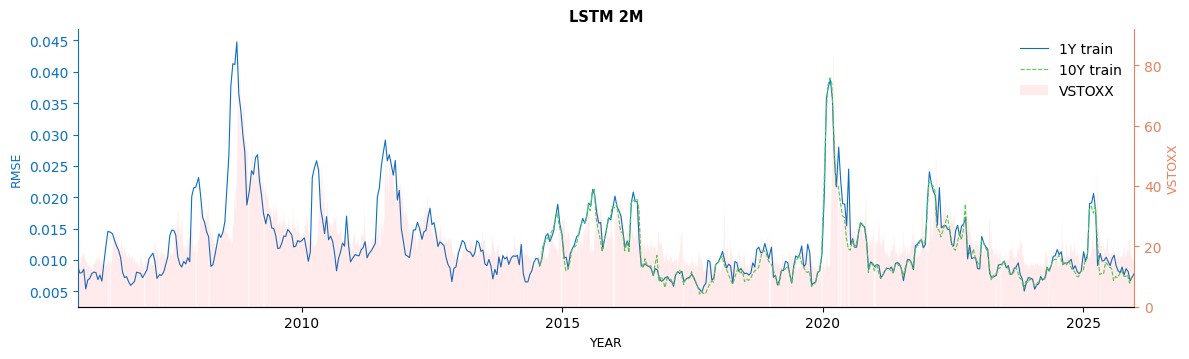

In [24]:
plot_rmse(results, "LSTM", "2M", vstoxx_df)

Display the **RMSE** error plot for the **LSTM 6M** model for both **1Y** and **10Y**.

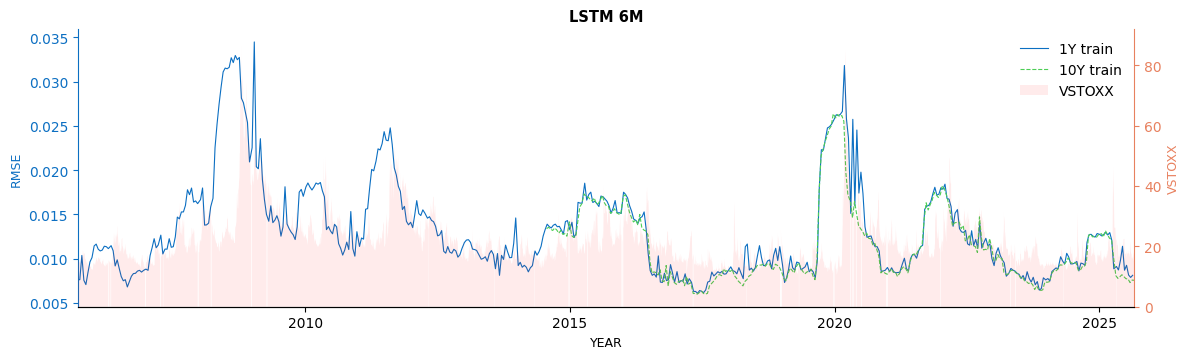

In [25]:
plot_rmse(results, "LSTM", "6M", vstoxx_df)

Display the **RMSE** error plot for the **MLP 2M** model for both **1Y** and **10Y**.

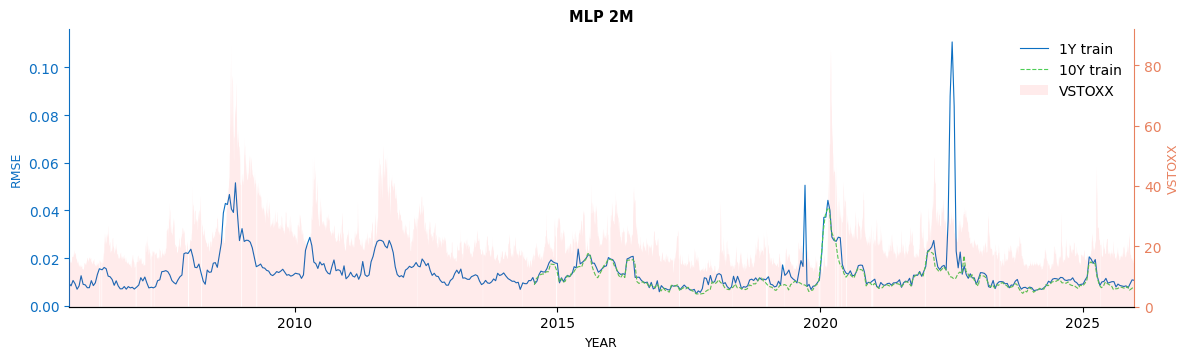

In [26]:
plot_rmse(results, "MLP",  "2M", vstoxx_df)

Display the **RMSE** error plot for the **MLP 6M** model for both **1Y** and **10Y**.

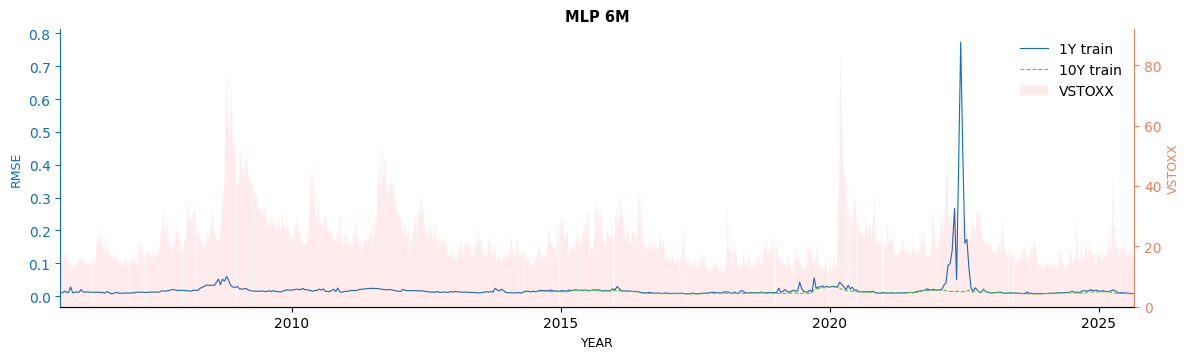

In [27]:
plot_rmse(results, "MLP",  "6M", vstoxx_df)

# **Statistical Testing of Financial Environment Changes**

First of all, i identify the **possible candidates for a structural change** by looking at the RMSE series (i chose **LSTM 1Y 2M**). i do this so that i can identify the exact date in the series.

In [ ]:
s = results.query("model=='LSTM' and train_years=='1Y' and horizon=='2M'").copy()  # filter the selected series
s["checkpoint_date"] = pd.to_datetime(s["checkpoint_date"])  # convert dates
s = s.sort_values("checkpoint_date")  # sort by date
s["rmse_dec"] = s["rmse"] / 100  # convert RMSE to decimal form: 4.5 -> 0.045

ticks = pd.date_range(s["checkpoint_date"].min(), s["checkpoint_date"].max(), freq="3YS")  # create x-axis ticks every 3 years

h = alt.selection_point(on="pointerover", nearest=True, fields=["checkpoint_date"], empty=False)  # mouse hover

b = alt.Chart(s).encode(  # chart base
    x=alt.X("checkpoint_date:T", title="", axis=alt.Axis(format="%Y", values=ticks)),
    y=alt.Y("rmse_dec:Q", title="RMSE", axis=alt.Axis(format=".3f")))  # y-axis = RMSE in decimal form
(
    b.mark_line(color="#0c6fc2")  # blue line
    + b.mark_point(opacity=0, size=120).encode(tooltip=[alt.Tooltip("checkpoint_date:T", title="Date", format="%Y-%m-%d"),
    alt.Tooltip("rmse_dec:Q", title="RMSE", format=".3f")]).add_params(h)  # invisible points with tooltip
    + b.mark_circle(size=70, color="#0050ac").encode(opacity=alt.condition(h, alt.value(1), alt.value(0)))  # visible dot only on hover
).properties(width=1300, height=350).configure_view(stroke=None).configure_axis(grid=False)  # final style

alt.LayerChart(...)

Now i want to test whether the errors before and after an event are **statistically different**, **without incorporating the information** that emerged during that period.

If the errors observed **after** the event turn out to be permanently **higher**, we will interpret this as a **change in the economic-financial environment**, which reduced the model’s ability to recognize market return patterns.

I define the time window within which to perform the test, as well as the extreme events; these data apply **both to the static test and to the adaptive test**.


In this part, i select an event and build a window of $140$ days before and $140$ days after the event, for a total of $280$ days. I then train the model on the $K$ days preceding the beginning of the event window and test it on the entire $280$ day window.

More precisely, i load the dataset $\texttt{df}$ and identify the event date directly on the full set of dates contained in the dataframe. In this way, the variable $\texttt{e}$ represents the row index associated with the event date. For example, if $\texttt{e} = 1000$, this means that the event corresponds to row $\texttt{df}[1000]$.

Then, in the $\texttt{run_event}$ function, i define the beginning and the end of the event window as

$$
a = e - WINDOW, \qquad b = e + WINDOW
$$

so that, if $\texttt{e} = 1000$ and $\texttt{WINDOW} = 140$, i obtain

$$
a = 860, \qquad b = 1140
$$

Here, $a$ and $b$ are day in the dataframe. This means that the model will be tested on the target days from row $860$ up to row $1139$, where row $1000$ corresponds to the event day.

At this point, i want to build the training dataset. The training set must contain the $K=252$ target days preceding the beginning of the event window. Therefore, if the test window starts at $a = 860$, the training targets must run from row $608$ up to row $859$, since

$$
860 - 252 = 608
$$

However, in order to actually generate these $252$ sequences through $\texttt{create_sequence(df_train)}$, it is not enough to take only the target rows, because each sequence also requires the previous $12$ observations used as input. For this reason, the training block must begin $12$ rows earlier,

$$
608 - 12 = 596
$$

As a consequence, the training set is defined as

$$
\texttt{df}[596\!:\!860]
$$

This slice includes rows $596, \ldots, 859$, because in Python the right endpoint is excluded. The first training sequence uses rows $596, \ldots, 607$ as input and row $608$ as target, while the last training sequence uses rows $847, \ldots, 858$ as input and row $859$ as target. Therefore, this block generates exactly the $252$ training sequences whose targets go from $608$ to $859$.

The same logic applies to the test window. I want to test the model on the target days from row $860$ up to row $1139$. Again, in order to construct these sequences, i must also include the previous $12$ observations needed to form the first input window. For this reason, the test block must start $12$ rows before $a$, that is, at row

$$
860 - 12 = 848
$$

Therefore, the test set is defined as

$$
\texttt{df}[848\!:\!1140]
$$

This slice includes rows $848, \ldots, 1139$. In particular, the first test sequence uses rows $848, \ldots, 859$ as input and row $860$ as target, while the last test sequence uses rows $1127, \ldots, 1138$ as input and row $1139$ as target.

In [ ]:
WINDOW = 140                                                                    # define a 140-day window before and after the event
EVENTS = [                                                                      # events taken into consideration
    ("2008 Financial Crisis", "2008-10-03"),
    ("Sovereign Debt Crisis", "2010-04-15"),
    ("Italy-Spain Contagion", "2011-08-10"),
    ("COVID-19", "2020-02-24"),
    ("Ukraine War / Energy Shock", "2022-01-18"),
    ("Tariff Shock / Trade War Fears", "2025-02-14"),
]
MODELS = [("MLP",1),("LSTM",1),("MLP",10),("LSTM",10)]                          # model combinations for training windows
ORDER  = ["MLP1Y","LSTM1Y","MLP10Y","LSTM10Y"]                                  # order used to plot the lines
COLORS = {"MLP1Y":"#007bc1","LSTM1Y":"#da4e0b","MLP10Y":"#fec459","LSTM10Y":"#904b92"} # colors of the series

df = load_data(DATA_PATH)                                                       # load the data

I define the function that, for a specific model-training-event combination, returns the series of the **error** to be analyzed with the **Ansari-Bradley test**.

In [ ]:
def run_event(df, model_type, train_years, event_date):
    dates = pd.DatetimeIndex(pd.to_datetime(df["Date"]))                        # assign at dates the time series df[Date]
    e = dates.get_indexer([pd.Timestamp(event_date)], method="nearest")[0]      # get the index of the event_date

    a, b, K = e - WINDOW, e + WINDOW, 252 * train_years                         # a=start of event window b=end of event window, K=training length
    if a - K - TIME_STEPS < 0 or b > len(df): return pd.DataFrame()             # if there are not enough rows return an empty dataframe

    tr = slice(a - K - TIME_STEPS, a)                                           # build training set, e.g. Xtr[596:860], ytr[596:860]
    te = slice(a - TIME_STEPS, b)                                               # build test set, e.g. Xte[848:1140], yte[848:1140]

    df_train = df.iloc[tr].reset_index(drop=True)                               # create the train df filtering df with tr es: df_train = df[596,860]
    df_test  = df.iloc[te].reset_index(drop=True)                               # create the test df filtering df with te es: df_test = df[848,1140]

    df_train, df_test = scale(df_train, df_test)                                # scale the df_train and the df_test

    Xtr, ytr, train_dates = create_sequence(df_train)                           # now i create train sequences after scaling
    Xte, yte, test_dates = create_sequence(df_test)                             # now i create test sequences after scaling

    tf.keras.backend.clear_session()                                            # clear session
    set_seed(SEED)                                                              # set seed for reproducibility

    if model_type == "MLP":                                                     # if MLP build the model
        model = build_mlp()
        Xtr = Xtr.reshape(len(Xtr), -1)                                         # flatten train input because MLP expects 2D input
        Xte = Xte.reshape(len(Xte), -1)                                         # flatten test input because MLP expects 2D input
    else:                                                                       # if LSTM build the model
        model = build_lstm()

    model.fit(Xtr, ytr, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)        # train the model on the training set
    err = model(Xte, training=False).numpy().ravel() - yte                      # predict on the event window and compute errors

    return pd.DataFrame({
        "model": f"{model_type}{train_years}Y",                                 # model type
        "Date": pd.to_datetime(test_dates),                                     # actual target dates of the event window
        "rel_day": np.arange(-WINDOW, WINDOW),                                  # day relative to the event
        "error": err                                                            # prediction error
    })

Now i run the models **combine all the results** into a single dataframe.

In [ ]:
frames = []                                                                     # initialize frames (list of dataframes)

for event_name, event_date in EVENTS:                                           # for each event
    for model_name, train_years in MODELS:                                      # and for each model
        event_result = run_event(df,model_name, train_years, event_date)        # run run_event by passing the model, the training years (1 or 10), and the event date
        event_result["event_name"] = event_name                                 # add a column with the event name
        frames.append(event_result)                                             # add event_result to the frames list

event_results = pd.concat(frames, ignore_index=True)                            # concatenate all dataframes in the list

In [ ]:
event_results.to_csv("results/event_results.csv", index=False)

If i don't want to re run the code i **import the results dataset**.

In [ ]:
#event_results=pd.read_csv("results/event_results.csv")

Graphically i show how the **forecasting errors of the models change around the main uncertainty events**. We can observe that market shocks disrupt the predictive ability of the models, generating **abnormal errors around extreme events**.

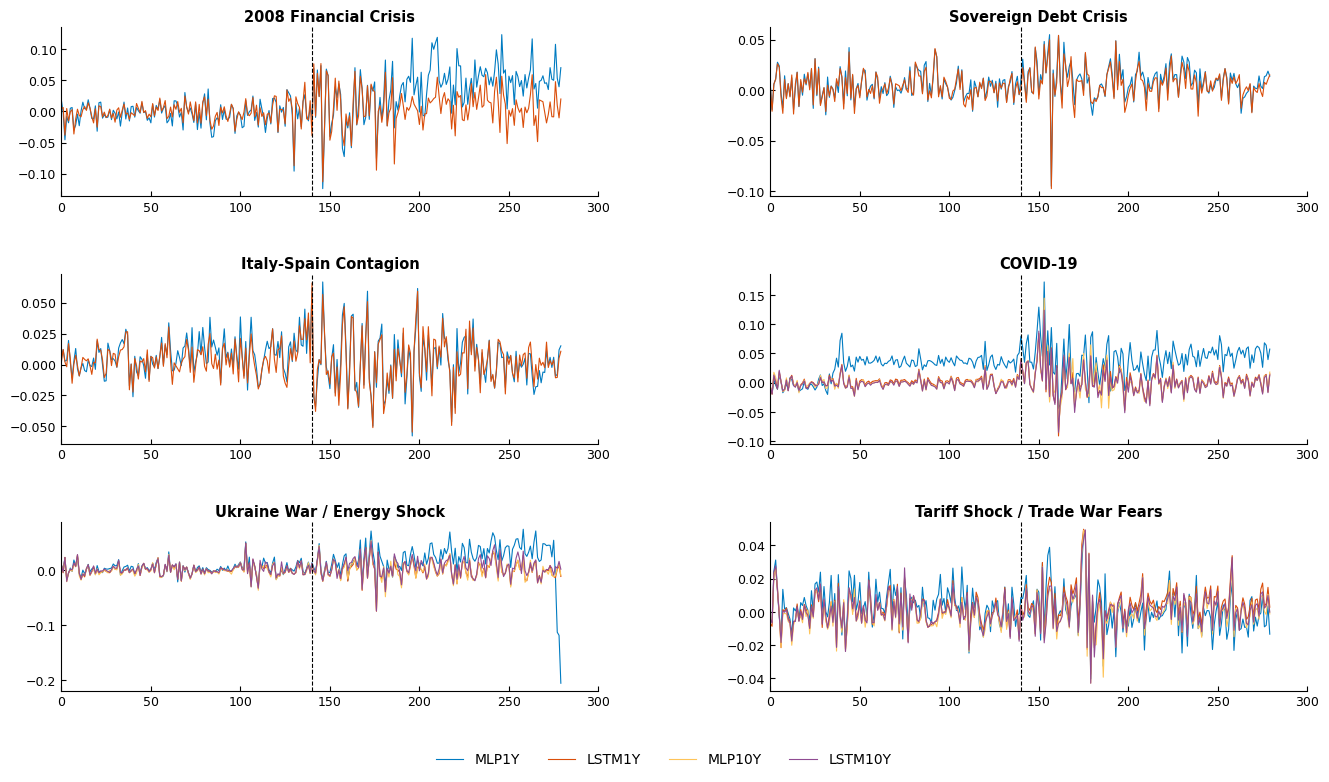

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))                                 # create a grid of plots with 3 rows and 2 columns axes is a matrix of axes

for i, (ax, event) in enumerate(zip(axes.flat, EVENTS)):                        # for each plot ax also take the corresponding event
    event_name = event[0]                                                       # get the event name

    for model in ORDER:                                                         # for each model
        s = event_results[(event_results["event_name"] == event_name) & (event_results["model"] == model)].sort_values("rel_day")  # filter the dataframe
        if not s.empty:                                                         # if the dataframe is not empty
            ax.plot(s["error"].values/100, lw=0.8, color=COLORS[model], label=model if i == 4 else "_nolegend_")

    ax.set_title(event_name, fontsize=10.5, fontweight="bold", pad=4)           # set event_name as the title
    ax.set_xlim(0, 300)                                                         # set the x-axis range
    ax.set_xticks(range(0, 301, 50))                                            # set x-axis ticks
    ax.axvline(140, color="black", lw=0.8, ls="--")                             # mark the event day
    ax.tick_params(direction="in", labelsize=9)                                 # make ticks point inward
    ax.spines["top"].set_visible(False)                                         # hide top border
    ax.spines["right"].set_visible(False)                                       # hide right border

fig.legend(loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.02))  # place the legend below all plots
fig.subplots_adjust(left=0.07, right=0.96, top=0.96, bottom=0.13, hspace=0.46, wspace=0.32)  # adjust margins and spacing between plots
plt.show()                                                                      # display the plots

The **Ansari-Bradley test** is based on the following hypotheses:

- $H_0$: the two samples come from the same distribution
- $H_1$: the two samples have the same median and shape, but different dispersion

I choose a significance level equal to $\alpha = 0.05$.

The decision rule is the following:

- if $p$-value $< \alpha$, I reject $H_0$ and conclude that there is evidence of a significant difference in dispersion between the two samples. Therefore, this suggests that something changed after the event.

- if $p$-value $\geq \alpha$, I do not reject $H_0$ and conclude that I do not have sufficient evidence to say that the errors changed significantly.

Now i **compute the p-values of the Ansari-Bradley test** for the **errors before and after the event** for each event and model, both including and excluding the event day, and build the final results table.

In [ ]:
rows = []                                                                       # initialize rows

for event_name, event_date in EVENTS:                                           # for each event
    for model in ORDER:                                                         # for each model
        s = event_results[(event_results["event_name"] == event_name) & (event_results["model"] == model)].sort_values("rel_day")  # filter by event and model, sorting by day

        if s.empty:  continue                                                   # if empty, show nothing

        before = s.loc[s["rel_day"] < 0, "error"]                               # filter values with rel_day < 0 (140 days before the event)
        after_with_event = s.loc[s["rel_day"] >= 0, "error"]                    # filter values with rel_day >= 0 (140 days after the event, including the event)
        after_without_event = s.loc[s["rel_day"] > 0, "error"]                  # filter values with rel_day > 0 (140 days after the event, excluding the event)

        p_with_event = ansari(before, after_with_event).pvalue                  # compute p-value from the Ansari-Bradley test for the window including the event
        p_without_event = ansari(before, after_without_event).pvalue            # compute p-value from the Ansari-Bradley test for the window excluding the event
        rows.append([event_name, model, p_with_event, p_without_event])         # add event name, model, and p-values to rows

t = pd.DataFrame(rows, columns=["Event", "Model", "Considering the event", "Without considering the event"])

tab_with = t.pivot(index="Event", columns="Model", values="Considering the event").reindex(columns=ORDER)            # pivot table considering the event
tab_without = t.pivot(index="Event", columns="Model", values="Without considering the event").reindex(columns=ORDER) # pivot table excluding the event

table3 = pd.concat([tab_with, tab_without], axis=1, keys=["Considering the event", "Without considering the event"]).round(5)  # concatenate the two pivot tables

display(table3.style.map(lambda v: "background-color:#f6c1c1" if pd.notna(v) and v >= 0.05 else "").format("{:.5f}"))  # highlight p-values > 0.05 in red

# **Model with adaptation**

In this part, i select an event and build a window of $140$ days before and $140$ days after the event, for a total of $280$ days. Unlike stage 2, however, i do not train the model only once before the event window. Instead, i retrain the model day by day, so that new information is progressively incorporated into the training set.

At this point, i want to build the training dataset for the first iteration of the loop. Since the first day evaluated in the event window is $i = 860$, the training set must contain the $K = 252$ days preceding that day. Therefore, the training targets must run from row $608$ up to row $859$, since

$$
860 - 252 = 608
$$

However, in order to actually generate these $252$ sequences through $\texttt{create_sequence(df_train)}$, it is not enough to take only the target rows, because each sequence also requires the previous $12$ observations used as input. For this reason, the training block must begin $12$ rows earlier,

$$
608 - 12 = 596
$$

As a consequence, for the first iteration the training set is defined as

$$
\texttt{df}[596\!:\!860]
$$

This slice includes rows $596, \ldots, 859$, because in Python the right endpoint is excluded. The first training sequence uses rows $596, \ldots, 607$ as input and row $608$ as target, while the last training sequence uses rows $847, \ldots, 858$ as input and row $859$ as target. Therefore, this block generates exactly the $252$ training sequences whose targets go from $608$ to $859$.

The same logic applies to the one-day test block. In the first iteration, i want to predict day $860$. Again, in order to construct this sequence, i must also include the previous $12$ observations needed to form the input window. For this reason, the test block must start $12$ rows before $860$, that is, at row

$$
860 - 12 = 848
$$

Therefore, the test set for the first iteration is defined as

$$
\texttt{df}[848\!:\!861]
$$

This slice includes rows $848, \ldots, 860$. In particular, the test sequence uses rows $848, \ldots, 859$ as input and row $860$ as target.

In the next iteration, the loop moves to $i = 861$. At this point, the training block shifts forward by one row and becomes

$$
\texttt{df}[597\!:\!861]
$$

while the one-day test block becomes

$$
\texttt{df}[849\!:\!862]
$$

Thus, the new test sequence uses rows $849, \ldots, 860$ as input and row $861$ as target.

This is exactly what is mean by saying that new information is progressively incorporated. When the model predicts day $860$, the training set ends at row $859$, so day $860$ has not yet been included in training. When the model moves to day $861$, the training set now ends at row $860$, so the information observed on day $860$ has been incorporated into the model.

More generally, for each day $i$ in the event window, the training block is defined as

$$
\texttt{df}[\,i - 252 - 12 : i\,]
$$

while the one-day test block is defined as

$$
\texttt{df}[\,i - 12 : i + 1\,]
$$

In this way, the model always predicts day $i$ using only information available up to day $i - 1$, while the training set is updated day by day as the loop moves through the event window.

In [ ]:
def run_adaptive_event(df, model_type, train_years, event_date):
    dates = pd.DatetimeIndex(pd.to_datetime(df["Date"]))                        # assign at dates the time series df[Date]
    e = dates.get_indexer([pd.Timestamp(event_date)], method="nearest")[0]      # get the index of the event_date
    a, b, K = e - WINDOW, e + WINDOW, 252 * train_years                         # a=start of event window b=end of event window, K=training length

    if a - K - TIME_STEPS < 0 or b > len(df):                                   # if there are not enough rows, return an empty dataframe
        return pd.DataFrame()

    rows = []                                                                   # initialize an empty list

    for i in range(a, b):                                                       # loop over all days in the event window
        tr = slice(i - K - TIME_STEPS, i)                                       # build training set
        te = slice(i - TIME_STEPS, i + 1)                                       # build test set

        df_train = df.iloc[tr].reset_index(drop=True)                           # create the train df filtering df with tr
        df_test  = df.iloc[te].reset_index(drop=True)                           # create the test df filtering df with te

        df_train, df_test = scale(df_train, df_test)                            # scale the df_train and the df_test

        Xtr, ytr, train_dates = create_sequence(df_train)                       # create train sequences after scaling
        Xte, yte, test_dates  = create_sequence(df_test)                        # create the single test sequence after scaling

        tf.keras.backend.clear_session()                                        # clear session
        set_seed(SEED)                                                          # set seed for reproducibility

        if model_type == "MLP":                                                 # if MLP build the model
            model = build_mlp()
            Xtr = Xtr.reshape(len(Xtr), -1)                                     # flatten train input because MLP expects 2D input
            Xte = Xte.reshape(len(Xte), -1)                                     # flatten test input because MLP expects 2D input
        else:                                                                   # if LSTM build the model
            model = build_lstm()

        model.fit(Xtr, ytr, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)    # train the model on the training set
        err = model(Xte, training=False).numpy().ravel()[0] - yte[0]            # predict only day i and compute errors

        rows.append({
            "Date": dates[i],                                                   # save the actual date of day i
            "rel_day": i - e,                                                   # save the relative day to the event es:-140...139
            "error": err,                                                       # save the error
            "model": f"{model_type}{train_years}Y"                              # save the model type and train years
        })

    return pd.DataFrame(rows)                                                   # return the final dataframe

Now i run the models and **combine all the results** into a single dataframe.

In [ ]:
frames = []                                                                     # initialize frames
for event_name, event_date in EVENTS:                                           # for each event
    for model_name, train_years in MODELS:                                      # for each model
        adaptive_result = run_adaptive_event(df, model_name, train_years, event_date) # run run_adaptive_event by passing the model, the training years (1 or 10)
        adaptive_result["event_name"] = event_name                              # add the columnn event_name
        frames.append(adaptive_result)                                          # add adaptive_result to the frames list

adaptive_results= pd.concat(frames, ignore_index=True)                          # concatenate all dataframe in the list

In [ ]:
adaptive_results.to_csv("results/adaptive_results.csv", index=False)

If i don't want to re run the code i **import the results dataset**.

In [ ]:
#adaptive_results=pd.read_csv("results/adaptive_results.csv")

Now i **compute the p-values of the Ansari-Bradley test** for the **errors before and after the event** for each event and model, both including and excluding the event day, and build the final results table.

In [ ]:
rows = []                                                                       # initialize rows

for event_name, event_date in EVENTS:                                           # for each event
    for model in ORDER:                                                         # for each model
        s = adaptive_results[(adaptive_results["event_name"] == event_name)
         & (adaptive_results["model"] == model)].sort_values("rel_day")         # filter by event and model, sorting by day

        if s.empty:  continue                                                   # if empty, show nothing

        before = s.loc[s["rel_day"] < 0, "error"]                               # filter values with rel_day < 0 (140 days before the event)
        after_with_event = s.loc[s["rel_day"] >= 0, "error"]                    # filter values with rel_day >= 0 (140 days after the event, including the event)
        after_without_event = s.loc[s["rel_day"] > 0, "error"]                  # filter values with rel_day > 0 (140 days after the event, excluding the event)

        p_with_event = ansari(before, after_with_event).pvalue                  # compute p-value from the Ansari-Bradley test for the window including the event
        p_without_event = ansari(before, after_without_event).pvalue            # compute p-value from the Ansari-Bradley test for the window excluding the event
        rows.append([event_name, model, p_with_event, p_without_event])         # add event name, model, and p-values to rows

t4 = pd.DataFrame(rows, columns=["Event", "Model", "Considering the event", "Without considering the event"])  # convert rows into a dataframe

tab_with = t4.pivot(index="Event", columns="Model", values="Considering the event").reindex(columns=ORDER)            # pivot table considering the event
tab_without = t4.pivot(index="Event", columns="Model", values="Without considering the event").reindex(columns=ORDER) # pivot table excluding the event

table4 = pd.concat([tab_with, tab_without], axis=1, keys=["Considering the event", "Without considering the event"]).round(5)  # concatenate the two pivot tables

display(table4.style.map(lambda v: "background-color:#f6c1c1" if pd.notna(v) and v >= 0.05 else "").format("{:.5f}"))  # highlight p-values > 0.05 in red

Now I define a function that graphically represents the **errors made by the model around the main crisis events**. In particular, the errors obtained in the case **without adaptation** are compared with those obtained in the case **with adaptation**, in which the model is provided with new information every day.

In [ ]:
def plot_event(EVENT):

    fig, axes = plt.subplots(4, 1, figsize=(10, 7))

    pairs = [("LSTM1Y", "Before"), ("LSTM1Y", "After"), ("LSTM10Y", "Before"), ("LSTM10Y", "After")]

    for ax, (model, when) in zip(axes, pairs):
        df_static = event_results[(event_results["event_name"] == EVENT) & (event_results["model"] == model)][["rel_day", "error"]]
        df_adaptive = adaptive_results[(adaptive_results["event_name"] == EVENT) & (adaptive_results["model"] == model)][["rel_day", "error"]]
        df = df_static.merge(df_adaptive, on="rel_day", suffixes=("_no", "_yes")).sort_values("rel_day")
        if when == "Before": df = df[df["rel_day"] < 0]
        else: df = df[df["rel_day"] >= 0]

        if df.empty:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)
            continue

        x = np.arange(len(df))
        y_no = df["error_no"].to_numpy(float) / 100
        y_yes = df["error_yes"].to_numpy(float) / 100
        ax.plot(x, y_no, lw=0.8, label="Without learning and adaptation")
        ax.plot(x, y_yes, lw=0.8, label="With learning and adaptation")
        m = np.nanmax(np.abs(np.r_[y_no, y_yes]))
        ax.set_ylim(-1.30 * m, 1.30 * m)
        model_lab = model.replace("LSTM1Y", "LSTM 1Y").replace("LSTM10Y", "LSTM 10Y")
        ax.set_title(f"{when} {EVENT}\n{model_lab}", fontsize=10, fontweight="bold", pad=4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(direction="in", labelsize=9)
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", bbox_to_anchor=(0.5, -0.01), ncol=2, frameon=False, fontsize=10)
    fig.subplots_adjust(hspace=0.9, left=0.07, right=0.98, top=0.95, bottom=0.13)
    plt.show()

Now I graphically show the errors before and after the event **2008 Financial Crisis**.

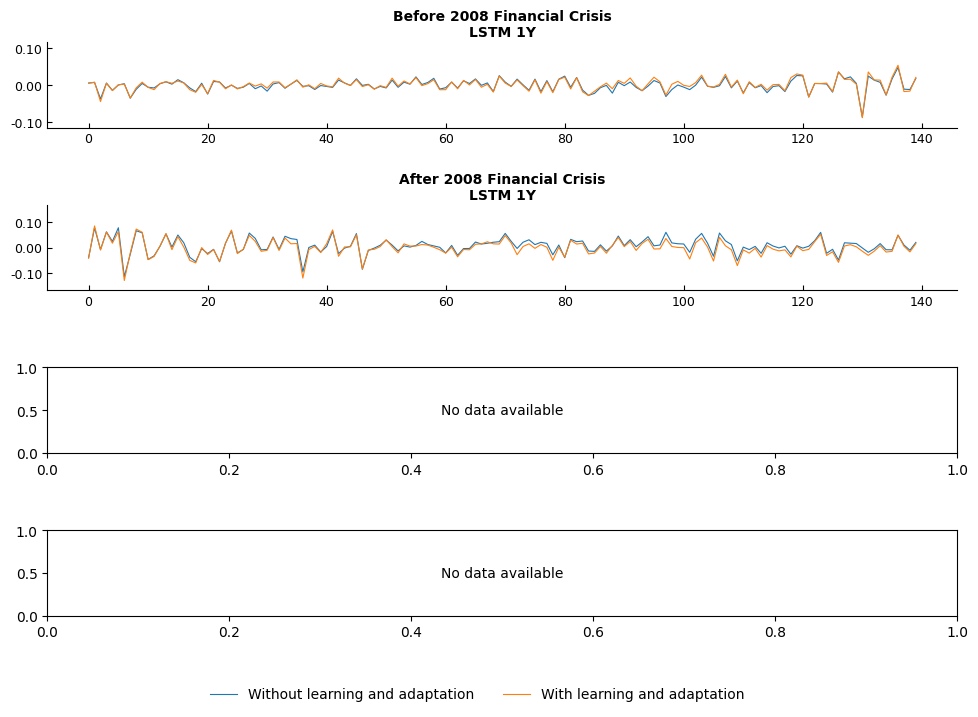

In [ ]:
plot_event("2008 Financial Crisis")

Now I graphically show the errors before and after the event **COVID-19**.

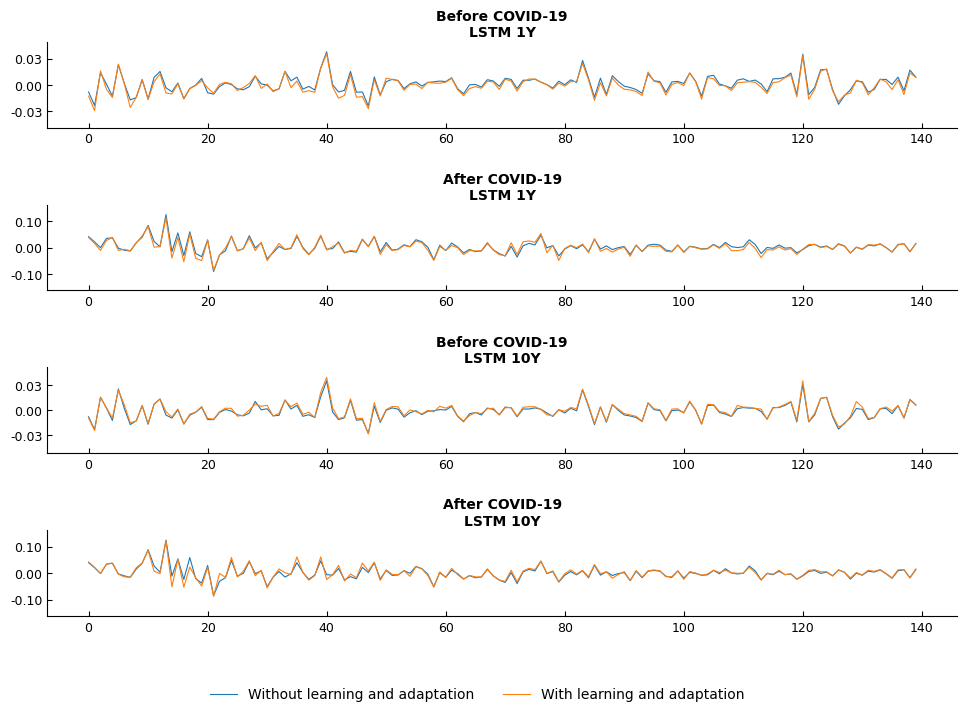

In [ ]:
plot_event("COVID-19")

Now I graphically show the errors before and after the event **Italy-Spain Contagion**.

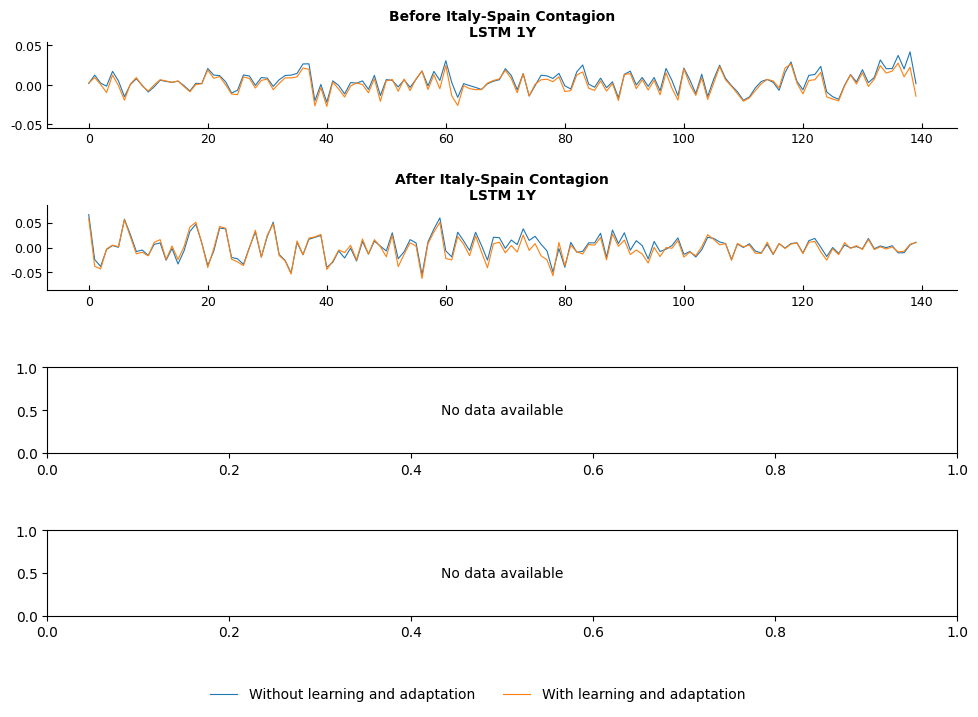

In [ ]:
plot_event("Italy-Spain Contagion")

Now I graphically show the errors before and after the event **Sovereign Debt Crisis**.

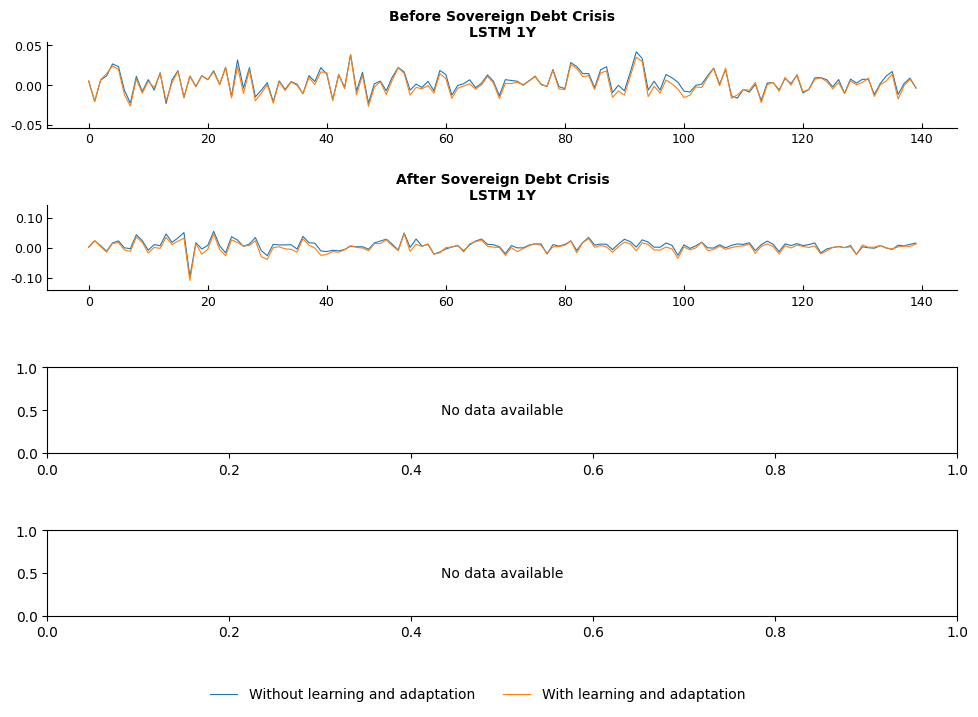

In [ ]:
plot_event("Sovereign Debt Crisis")

Now I graphically show the errors before and after the event **Tariff Shock / Trade War Fears**.

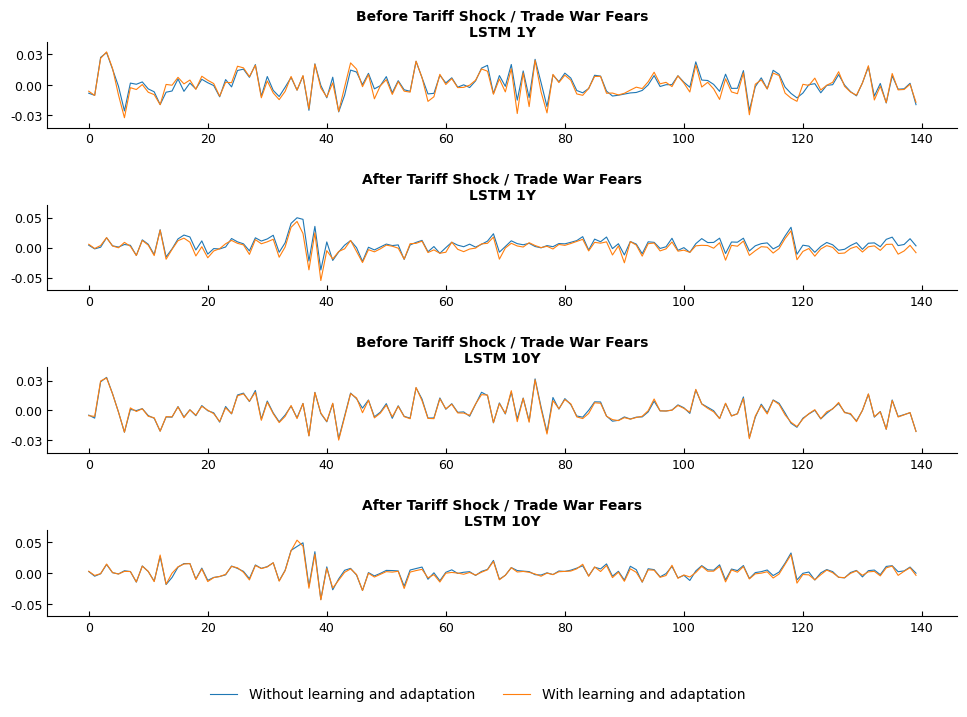

In [ ]:
plot_event("Tariff Shock / Trade War Fears")

Now I graphically show the errors before and after the event **Ukraine War / Energy Shock**.

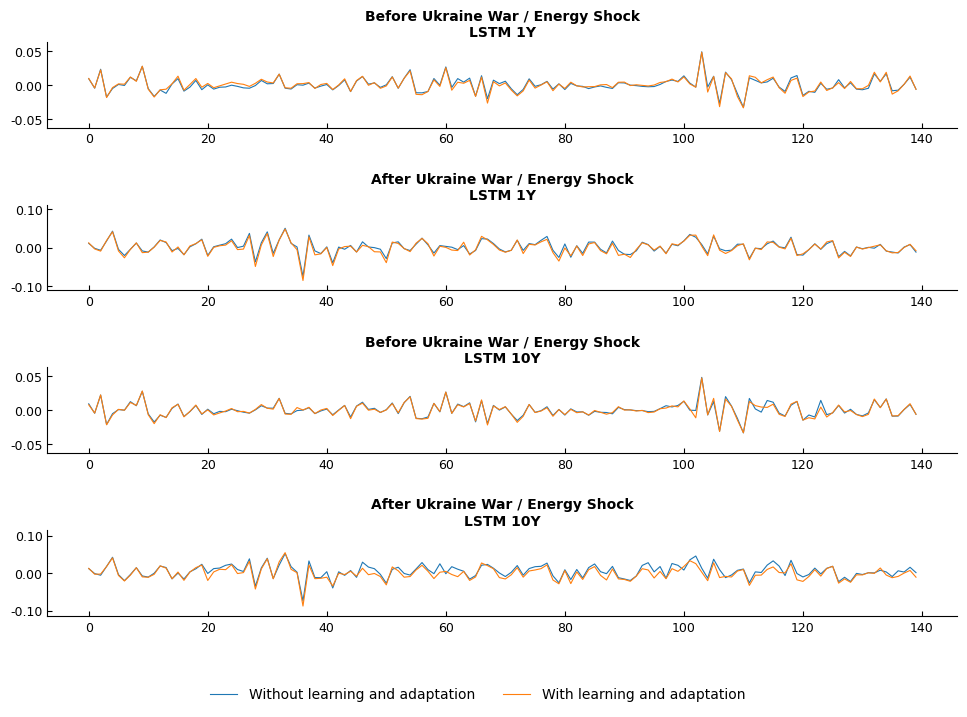

In [ ]:
plot_event("Ukraine War / Energy Shock")

# **Details of RMSE before and after high uncertainty events**

Now i show the detail of the **RMSE before and after each event**, with and without adaption, and by training time.

In [ ]:
rows = []

for e in event_results["event_name"].drop_duplicates():
    for y in [1, 10]:
        r = {"Event": f"{e} {y}Y training"}

        for name, df, m in [
            ("Static LSTM", event_results, f"LSTM{y}Y"),
            ("Dynamic LSTM", adaptive_results, f"LSTM{y}Y"),
            ("Static MLP", event_results, f"MLP{y}Y"),
            ("Dynamic MLP", adaptive_results, f"MLP{y}Y")
        ]:
            d = df[(df["event_name"] == e) & (df["model"] == m)]

            before_err = d.loc[d["rel_day"] < 0, "error"].dropna().values
            after_err = d.loc[d["rel_day"] >= 0, "error"].dropna().values

            before = rmse(np.zeros_like(before_err), before_err) if len(before_err) else np.nan
            after = rmse(np.zeros_like(after_err), after_err) if len(after_err) else np.nan

            r[(name, "Before")] = before
            r[(name, "After")] = after
            r[(name, "Diff.")] = after - before

        if pd.Series(r).drop("Event").notna().any():
            rows.append(r)

table_rmse = pd.DataFrame(rows).set_index("Event")
table_rmse.columns = pd.MultiIndex.from_tuples(table_rmse.columns)

table_rmse_pct = table_rmse.map(lambda x: "" if pd.isna(x) else f"{x:.2f}%")

table_rmse_pct

Static LSTM               Dynamic LSTM               Static MLP               Dynamic MLP              
                                                 Before  After  Diff.       Before  After  Diff.     Before  After  Diff.      Before  After  Diff.
Event                                                                                                                                              
2008 Financial Crisis 1Y training                 1.60%  3.23%  1.64%        1.67%  3.29%  1.62%      1.85%  5.48%  3.63%       1.87%  3.46%  1.60%
Sovereign Debt Crisis 1Y training                 1.31%  1.87%  0.56%        1.27%  1.78%  0.51%      1.35%  2.03%  0.68%       1.35%  1.93%  0.58%
Italy-Spain Contagion 1Y training                 1.29%  2.17%  0.88%        1.20%  2.22%  1.02%      1.53%  2.22%  0.69%       1.29%  2.33%  1.03%
COVID-19 1Y training                              0.83%  2.48%  1.65%        0.87%  2.54%  1.67%      3.31%  5.18%  1.87%       1.01%  2.62%  1.61%
COVID-19 10Y training                             0.82%  2.47%  1.65%        0.84%  2.62%  1.78%      0.83%  2.63%  1.81%       0.86%  2.71%  1.85%
Ukraine War / Energy Shock 1Y training            1.03%  1.70%  0.67%        1.07%  1.83%  0.77%      1.12%  3.90%  2.78%       1.14%  1.93%  0.79%
Ukraine War / Energy Shock 10Y training           1.05%  1.86%  0.81%        1.06%  1.79%  0.73%      1.04%  1.76%  0.72%       1.03%  1.78%  0.75%
Tariff Shock / Trade War Fears 1Y training        0.91%  1.30%  0.39%        0.98%  1.24%  0.26%      1.15%  1.38%  0.23%       1.02%  1.28%  0.26%
Tariff Shock / Trade War Fears 10Y training       0.92%  1.24%  0.31%        0.92%  1.23%  0.31%      0.94%  1.25%  0.31%       0.93%  1.23%  0.30%